# ETF Markowitz Portfolio Backtest

Weekly-rebalanced **Markowitz mean-variance** backtest over a fixed 7-ETF universe,
fully invested (long-only, weights sum to 1). Two objectives are run side by side —
**max-Sharpe** and **min-variance** — against two benchmarks: **equal-weight (1/7)**
and **SPY** (`^GSPC`, buy-and-hold).

This notebook is independent of the ML stock pipeline. It reuses only the *pure*
backtest helpers from `src/backtest_lib.py` (`compute_metrics`, `_drift_weights`)
and mirrors that module's `$0.02/share` spread cost model and gross-vs-net reporting.

- Universe: `QQQ, VOO, VGT, SOXX, QUAL, VBR, VTV`
- Weekly bars (W-FRI), trailing 52-week covariance, rebalanced every week.
- A separate idea (the 50%-ETFs / 50%-cash fixed allocation) is documented in
  `docs/ml_plan_etf_50_50_cash.md` and intentionally NOT implemented here.

In [1]:
import sys, os
sys.path.append("src")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from pypfopt import expected_returns, risk_models
from pypfopt.efficient_frontier import EfficientFrontier

from src.ml_stock_prediction.backtest_lib import compute_metrics, _drift_weights, WEEKS_PER_YEAR

# ---- config (all tunable) ----
UNIVERSE        = ["QQQ", "VOO", "VGT", "SOXX", "QUAL", "VBR", "VTV", "IGV"]
BENCH           = "^GSPC"          # SPY proxy
COV_LOOKBACK    = 52               # trailing weeks for mu / covariance
SPREAD_PER_SHARE = 0.02            # $/share bid-ask; conservative for liquid ETFs (try 0.01)
RISK_FREE       = 0.0              # weekly-annualized rf for Sharpe / max-Sharpe
DATA_START      = "2015-01-01"
PRICE_CSV       = "data/etf_prices.csv"
print(f"{len(UNIVERSE)} ETFs + {BENCH}; cov lookback {COV_LOOKBACK}w; spread ${SPREAD_PER_SHARE}/sh")

8 ETFs + ^GSPC; cov lookback 52w; spread $0.02/sh


## 1. Data — weekly W-FRI closes (cached)

Per-ticker incremental cache mirroring `Main.ipynb`'s `download_and_fix_yfinance_data`:
columns already fresh through the most recent Friday are reused; the rest are
re-fetched. Pass `force_refresh=True` to rebuild from scratch.

In [2]:
def _last_friday():
    today = pd.Timestamp.today().normalize()
    return today - pd.Timedelta(days=(today.weekday() - 4) % 7)


def download_weekly_closes(tickers, csv_path=PRICE_CSV, start=DATA_START,
                           force_refresh=False):
    """Wide weekly (W-FRI) auto-adjusted close matrix: Date x ticker.

    Reuses cached columns whose last value reaches the most recent Friday;
    only missing/stale tickers are downloaded. Writes the merged matrix back
    to csv_path (gitignored)."""
    threshold = _last_friday() - pd.Timedelta(days=1)

    cached, fresh = None, set()
    if not force_refresh and os.path.exists(csv_path):
        cached = pd.read_csv(csv_path, parse_dates=["Date"]).set_index("Date")
        for col in cached.columns:
            s = cached[col].dropna()
            if not s.empty and s.index.max() >= threshold:
                fresh.add(col)

    to_dl = [t for t in tickers if t not in fresh]
    print(f"{len(tickers) - len(to_dl)} cached + fresh; {len(to_dl)} to fetch from yfinance")

    frames = []
    for t in to_dl:
        df = yf.download(t, interval="1d", start=start,
                         auto_adjust=True, progress=False)
        if df.empty:
            print(f"  WARNING: no data for {t}")
            continue
        close = df["Close"]                      # handle MultiIndex or flat columns
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
        wk = close.resample("W-FRI").last()
        wk.name = t
        frames.append(wk)

    new = pd.concat(frames, axis=1) if frames else None
    if cached is not None:
        keep = cached[[c for c in cached.columns if c in fresh]]
        combined = keep if new is None else pd.concat([keep, new], axis=1)
    else:
        combined = new
    combined = combined.sort_index()
    combined = combined[[t for t in tickers if t in combined.columns]]  # order + prune
    combined.index.name = "Date"
    combined.to_csv(csv_path)
    return combined


prices = download_weekly_closes(UNIVERSE + [BENCH]).ffill()
closes = prices[UNIVERSE].dropna()        # weeks where all 7 ETFs exist
spy_close = prices[BENCH].reindex(closes.index)
print(closes.shape, "|", closes.index.min().date(), "->", closes.index.max().date())
closes.tail()

8 cached + fresh; 1 to fetch from yfinance
(597, 8) | 2015-01-02 -> 2026-06-05


,QQQ,VOO,VGT,SOXX,QUAL,VBR,VTV,IGV
Date,,,,,,,,
2026-05-08,711.229980,678.039978,112.440002,520.299988,210.429993,233.570007,207.039993,91.150002
2026-05-15,708.929993,679.440002,113.309998,508.519989,210.449997,227.289993,206.669998,91.779999
2026-05-22,717.539978,685.549988,115.750000,537.330017,214.380005,232.669998,210.899994,94.010002
2026-05-29,729.349976,690.395020,117.388802,561.549988,215.399994,235.345001,211.985001,101.660004
2026-06-05,729.349976,690.395020,117.388802,561.549988,215.399994,235.345001,211.985001,107.699997


## 2. Returns

`weekly_ret.loc[t]` is the realized return over the week *ending* at `t`. The
backtest chooses weights from information up to and including `t`, so the PnL it
earns is next week's return — `fwd_ret = weekly_ret.shift(-1)` (i.e.
`fwd_ret.loc[t]` = return from `t` to `t+1`). The final week has no forward return
and is dropped from the simulation.

In [3]:
weekly_ret = closes.pct_change()
spy_ret    = spy_close.pct_change()

fwd_ret = weekly_ret.shift(-1)     # fwd_ret.loc[t] = ETF return t -> t+1 (the PnL)
spy_fwd = spy_ret.shift(-1)
fwd_ret.tail(3)

,QQQ,VOO,VGT,SOXX,QUAL,VBR,VTV,IGV
Date,,,,,,,,
2026-05-22,0.016459,0.007067,0.014158,0.045075,0.004758,0.011497,0.005145,0.081374
2026-05-29,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.059414
2026-06-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Weighting schemes

Long-only, fully invested, annualized at weekly frequency (`frequency=52`) — the
same correctness fix called out in `backtest_lib.max_sharpe_weights`. Each returns
`{ticker: weight}` and falls back to equal weight if the optimizer fails or the
covariance is degenerate.

In [4]:
def _equal(cols):
    cols = list(cols)
    return {c: 1.0 / len(cols) for c in cols} if cols else {}


def _ef(close_window):
    """Shared EfficientFrontier on trailing prices, or None if not enough data."""
    cw = close_window.dropna(axis=1, how="any")
    if cw.shape[1] < 2 or cw.shape[0] < 3:
        return None, cw
    mu = expected_returns.mean_historical_return(cw, frequency=WEEKS_PER_YEAR)
    S = risk_models.sample_cov(cw, frequency=WEEKS_PER_YEAR)
    return EfficientFrontier(mu, S), cw


def max_sharpe_weights_etf(close_window, risk_free_rate=RISK_FREE):
    ef, cw = _ef(close_window)
    if ef is None:
        return _equal(cw.columns)
    try:
        ef.max_sharpe(risk_free_rate=risk_free_rate)
        w = {k: v for k, v in ef.clean_weights().items() if v != 0.0}
        return w or _equal(cw.columns)
    except Exception:
        return _equal(cw.columns)


def min_variance_weights_etf(close_window):
    ef, cw = _ef(close_window)
    if ef is None:
        return _equal(cw.columns)
    try:
        ef.min_volatility()
        w = {k: v for k, v in ef.clean_weights().items() if v != 0.0}
        return w or _equal(cw.columns)
    except Exception:
        return _equal(cw.columns)


SCHEMES = {
    "max_sharpe":   max_sharpe_weights_etf,
    "min_variance": min_variance_weights_etf,
    "equal_weight": lambda cw: _equal(cw.columns),
}
print("schemes:", list(SCHEMES))

schemes: ['max_sharpe', 'min_variance', 'equal_weight']


## 4. Weekly rebalance loop

Each week after the first `COV_LOOKBACK` weeks: compute target weights from the
trailing window, pay a spread cost on the change versus last week's *drifted* book
(`(spread/2)/price · |Δw|` per ETF, the exact formula from `backtest_lib`), earn
`gross = Σ wᵢ·rᵢ`, then drift the book into next week. Per-ETF target weights are
stored so concentration can be plotted.

The loop now runs **independently per calendar year**: the book resets to cash each January (the first week buys from cash) and is dropped at year-end, so each year is an isolated backtest. The trailing covariance window still spans prior-year closes.

In [5]:
# Independent per-calendar-year backtest. run_backtest replays the weekly
# rebalance loop over a given set of dates with the book starting in CASH
# (cur = {}), so each year is isolated: bought fresh every January, dropped at
# year-end. The trailing COV_LOOKBACK window still spans prior-year closes.
def run_backtest(loop_dates, schemes=SCHEMES):
    cur = {s: {} for s in schemes}        # current (drifted) book per scheme
    records = []
    for t in loop_dates:
        fwd_row = fwd_ret.loc[t]
        if fwd_row.isna().all():          # last week: no realized forward return
            continue
        close_window = closes.loc[:t].tail(COV_LOOKBACK)
        price_row = close_window.iloc[-1]
        row = {"Date": t}
        for s, fn in schemes.items():
            target = fn(close_window)
            keys = set(target) | set(cur[s])
            turnover, cost = 0.0, 0.0
            for k in keys:
                dw = abs(target.get(k, 0.0) - cur[s].get(k, 0.0))
                if dw == 0.0:
                    continue
                turnover += dw
                price = price_row.get(k, np.nan)
                if pd.notna(price) and price > 0:
                    cost += (SPREAD_PER_SHARE / 2.0) / float(price) * dw
            gross = sum(w * float(fwd_row.get(k, 0.0))
                        for k, w in target.items() if pd.notna(fwd_row.get(k, np.nan)))
            net = gross - cost
            cur[s] = _drift_weights(target, fwd_row, gross)   # carry to next week
            row[f"{s}_gross"]    = gross
            row[f"{s}_net"]      = net
            row[f"{s}_turnover"] = turnover
            row[f"{s}_n"]        = sum(1 for v in target.values() if v > 0)
            for k in UNIVERSE:                                # target weight snapshot
                row[f"{s}__{k}"] = target.get(k, 0.0)
        records.append(row)
    if not records:
        return pd.DataFrame()
    wk = pd.DataFrame(records).set_index("Date").sort_index()
    wk["spy_net"] = spy_fwd.reindex(wk.index)
    return wk


dates = closes.index
eligible = dates[COV_LOOKBACK:]            # weeks with a full trailing window
annual = {}                                # year -> weekly frame (cash-reset)
for yr in sorted({d.year for d in eligible}):
    wk = run_backtest([t for t in eligible if t.year == yr])
    if len(wk):
        annual[yr] = wk

# concatenate the per-year frames -> one continuous (annually-reset) book so the
# downstream metrics / equity / weight cells keep working unchanged.
weekly = pd.concat(annual.values()).sort_index()
print(f"{len(annual)} annual backtests: {min(annual)}-{max(annual)} | "
      f"{len(weekly)} live weeks {weekly.index.min().date()} -> {weekly.index.max().date()}")
weekly.filter(regex="_net$").tail()


C:\Users\Unity\miniconda3\envs\ml-trading\Lib\site-packages\pypfopt\base_optimizer.py:307: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  self._opt.solve(
C:\Users\Unity\miniconda3\envs\ml-trading\Lib\site-packages\pypfopt\base_optimizer.py:307: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  self._opt.solve(


11 annual backtests: 2016-2026 | 544 live weeks 2016-01-01 -> 2026-05-29


,max_sharpe_net,min_variance_net,equal_weight_net,spy_net
Date,,,,
2026-05-01,0.117123,0.008653,0.043620,0.023348
2026-05-08,-0.022641,-0.001106,-0.004719,0.001293
2026-05-15,0.053441,0.020772,0.023304,0.008770
2026-05-22,0.045069,0.011148,0.023191,0.007050
2026-05-29,0.000000,0.004302,0.007426,0.000000


## 4b. Per-year results

Each calendar year is an independent backtest (book reset to cash each January),
so the table below shows where each scheme actually earned its return. `_ret` is
that year's total return, `_sharpe` its annualized Sharpe. (CAGR is omitted: a
partial first/last year would extrapolate and mislead.)


In [6]:
# Per-year total return + Sharpe for each scheme and SPY, computed on each year's
# own (cash-reset) net-return series.
_cols = list(SCHEMES) + ["spy"]
_rows = []
for _yr, _wk in annual.items():
    _r = {"year": _yr, "n_weeks": len(_wk)}
    for _s in _cols:
        _m = compute_metrics(_wk[f"{_s}_net"], risk_free_rate=RISK_FREE)
        _r[f"{_s}_ret"]    = _m["total_return"]
        _r[f"{_s}_sharpe"] = _m["sharpe"]
    _rows.append(_r)
annual_metrics = pd.DataFrame(_rows).set_index("year").round(4)
annual_metrics


,n_weeks,max_sharpe_ret,max_sharpe_sharpe,min_variance_ret,min_variance_sharpe,equal_weight_ret,equal_weight_sharpe,spy_ret,spy_sharpe
year,,,,,,,,,
2016,53,0.1845,0.9528,0.1416,1.1311,0.1784,1.1679,0.1140,0.9163
2017,52,0.2792,2.2439,0.2229,3.3937,0.2966,3.4830,0.2047,3.2141
2018,52,0.0353,0.2644,-0.1001,-0.5020,-0.0487,-0.1630,-0.0770,-0.3512
2019,52,0.4361,2.4598,0.2622,2.1206,0.3659,2.5239,0.2776,2.3168
2020,52,0.3445,1.0313,0.3153,1.0150,0.2940,0.9432,0.1611,0.6308
2021,53,0.0815,0.5268,0.2146,1.5878,0.2430,1.5416,0.2452,1.8470
2022,52,-0.0563,-0.1273,-0.0347,-0.0805,-0.1945,-0.6894,-0.1672,-0.6779
2023,52,0.0921,0.5195,0.0675,0.5752,0.3230,1.7688,0.2059,1.4483
2024,52,0.2120,1.5015,0.1862,1.6467,0.2688,1.5534,0.2651,1.9877


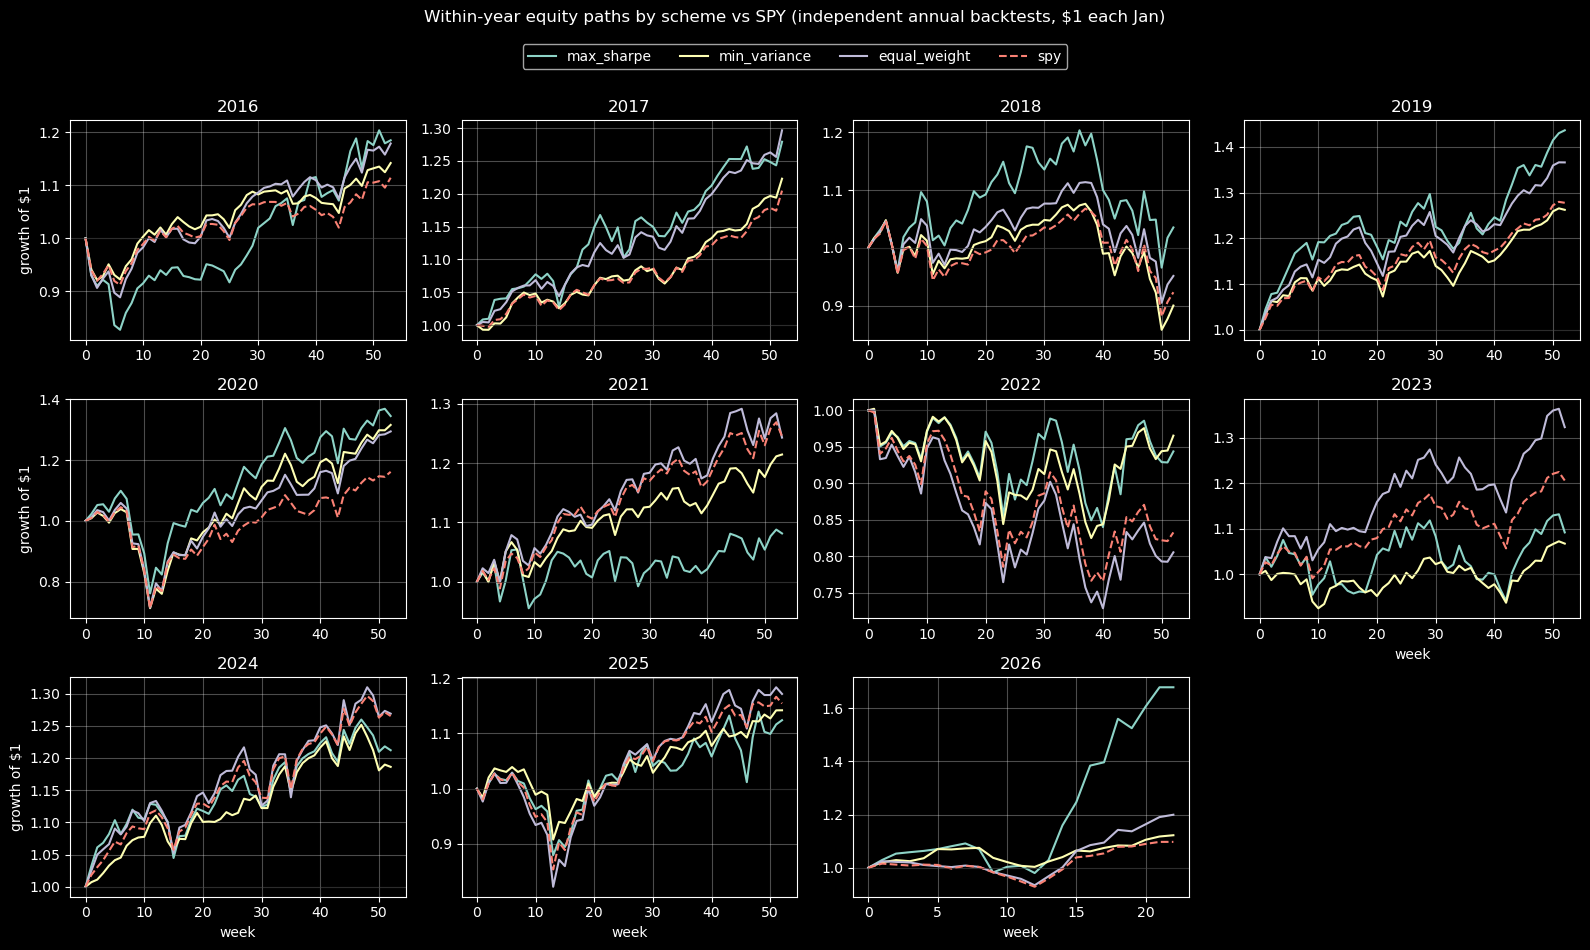

In [7]:
# One panel per calendar year: within-year equity path (growth of $1) for each
# scheme + SPY. Each year's book starts in cash, so every panel starts at $1.
_cols = list(SCHEMES) + ["spy"]
_years = list(annual)
_ncols = 4
_nrows = int(np.ceil(len(_years) / _ncols))
fig, axes = plt.subplots(_nrows, _ncols, figsize=(4 * _ncols, 3 * _nrows),
                         squeeze=False)
_lines, _labels = [], []
for _i, _yr in enumerate(_years):
    _ax = axes.flat[_i]
    _wk = annual[_yr]
    for _s in _cols:
        _eq = np.concatenate(
            [[1.0], (1.0 + _wk[f"{_s}_net"].fillna(0.0)).cumprod().to_numpy()])
        _ln, = _ax.plot(range(len(_eq)), _eq, lw=1.5,
                        ls="--" if _s == "spy" else "-")
        if _i == 0:                       # capture handles once for a shared legend
            _lines.append(_ln); _labels.append(_s)
    _ax.set_title(str(_yr)); _ax.axhline(1.0, color="k", lw=0.6, alpha=0.5)
    _ax.grid(alpha=0.3)
    if _i % _ncols == 0:
        _ax.set_ylabel("growth of $1")
    if _i >= len(_years) - _ncols:
        _ax.set_xlabel("week")
for _ax in axes.flat[len(_years):]:       # hide unused panels
    _ax.set_visible(False)
fig.legend(_lines, _labels, loc="upper center", ncol=len(_cols),
           bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Within-year equity paths by scheme vs SPY "
             "(independent annual backtests, $1 each Jan)", y=1.05)
plt.tight_layout()
plt.show()


## 5. Metrics & equity curves

In [8]:
equity = pd.DataFrame(index=weekly.index)
metrics = {}
for s in list(SCHEMES) + ["spy"]:
    net = weekly[f"{s}_net"]
    equity[s] = (1.0 + net.fillna(0.0)).cumprod()
    metrics[s] = compute_metrics(net, risk_free_rate=RISK_FREE)

metrics_df = pd.DataFrame(metrics).T[
    ["n_weeks", "total_return", "cagr", "ann_vol", "sharpe", "max_drawdown"]]
metrics_df.round(4)

,n_weeks,total_return,cagr,ann_vol,sharpe,max_drawdown
max_sharpe,544.0,6.7198,0.2158,0.2177,1.0076,-0.3073
min_variance,544.0,2.9684,0.1408,0.1613,0.8990,-0.3138
equal_weight,544.0,5.0667,0.1881,0.1922,0.9947,-0.3250
spy,544.0,2.6822,0.1327,0.1697,0.8208,-0.3181


In [9]:
print("gross vs net (transaction-cost drag) + average weekly turnover\n")
for s in SCHEMES:
    g = (1 + weekly[f"{s}_gross"].fillna(0)).prod() - 1
    n = (1 + weekly[f"{s}_net"].fillna(0)).prod() - 1
    print(f"{s:13s} gross {g:+.3f} | net {n:+.3f} | cost drag {g - n:+.4f}"
          f" | avg turnover {weekly[f'{s}_turnover'].mean():.3f}")

gross vs net (transaction-cost drag) + average weekly turnover

max_sharpe    gross +6.989 | net +6.720 | cost drag +0.2690 | avg turnover 0.410
min_variance  gross +2.989 | net +2.968 | cost drag +0.0207 | avg turnover 0.106
equal_weight  gross +5.079 | net +5.067 | cost drag +0.0127 | avg turnover 0.029


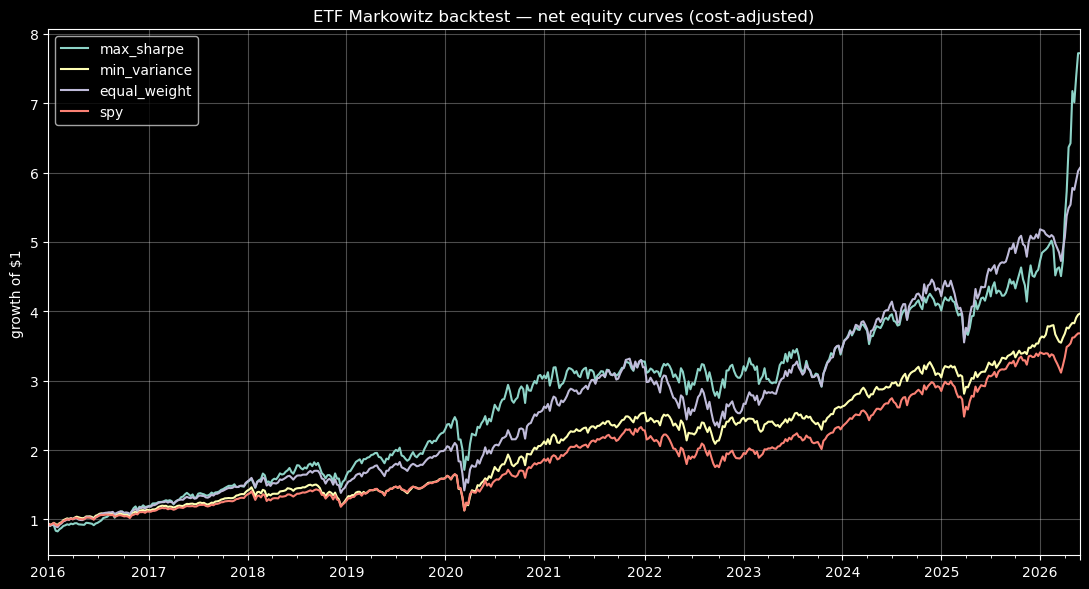

In [10]:
ax = equity.plot(figsize=(11, 6),
                 title="ETF Markowitz backtest — net equity curves (cost-adjusted)")
ax.set_ylabel("growth of $1"); ax.set_xlabel("")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Max-Sharpe weight concentration

Max-Sharpe tends to pile into one or two names — the concentration-vol problem
documented for the stock strategy. This stacked area shows how lumpy the book is
versus the flat 1/7 benchmark.

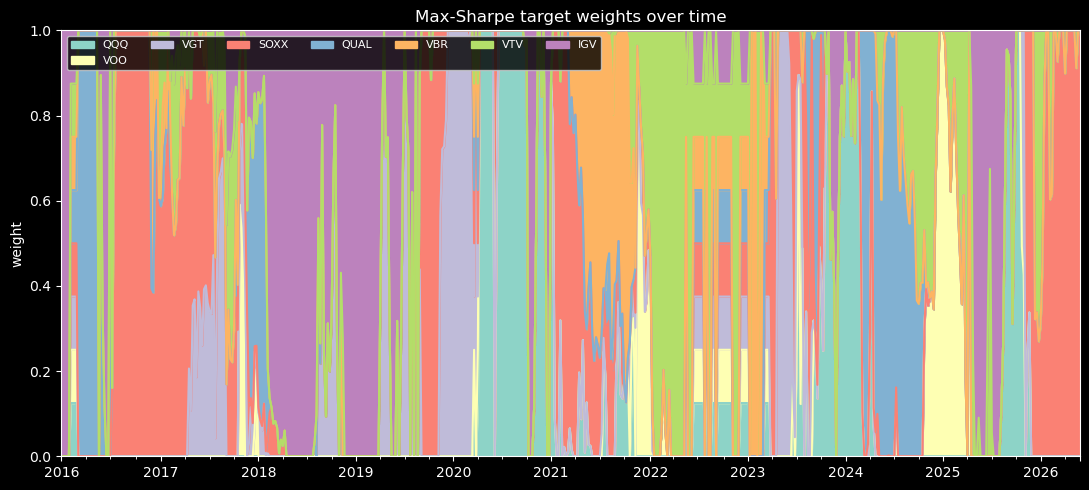

In [11]:
ms_w = weekly[[f"max_sharpe__{k}" for k in UNIVERSE]].copy()
ms_w.columns = UNIVERSE
ax = ms_w.plot.area(figsize=(11, 5),
                    title="Max-Sharpe target weights over time")
ax.set_ylim(0, 1); ax.set_ylabel("weight"); ax.set_xlabel("")
ax.legend(loc="upper left", ncol=7, fontsize=8)
plt.tight_layout(); plt.show()

## 6. Takeaways

_Fill in after the first run:_

- Does either Markowitz objective beat **equal-weight (1/7)** and **SPY**, *net of cost*?
- Does **min-variance** (lower turnover, less concentrated) hold up better than **max-Sharpe**?
- How concentrated does max-Sharpe get, and does that line up with the
  concentration-vol finding in `memory/project_backtest_no_edge.md`?